In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

os.makedirs('figures', exist_ok=True)

plt.rcParams.update({
    'font.size':       16,
    'axes.titlesize':  20,
    'axes.labelsize':  18,
    'xtick.labelsize': 20,
    'ytick.labelsize': 16,
    'legend.fontsize': 24,
})

# ── Load data ─────────────────────────────────────────────────────────────────
df  = pd.read_csv('Results/paper.csv')   # SNAIL
dft = pd.read_csv('Results/ibm.csv')     # IBM Brisbane

# Normalise to 'config' column regardless of schema version
if 'config' in df.columns:
    df['config'] = df['config'].replace({'Standard SABRE': 'SABRE', 'Standard MIRAGE': 'MIRAGE'})
else:
    df['config'] = df['router']          # new schema

if 'config' in dft.columns:
    dft['config'] = dft['config'].replace({'Standard SABRE': 'SABRE', 'Standard MIRAGE': 'MIRAGE'})
else:
    dft['config'] = dft['router']

# Normalise topo column
if 'wraparound' in df.columns:
    df['topo'] = df['device'] + df['wraparound'].map({True: '_wrap', False: ''})
else:
    df['topo'] = df['device']
    df['wraparound'] = False

dft['topo'] = dft['device']

# ── Constants ─────────────────────────────────────────────────────────────────
CONFIG_ORDER = ['SABRE', 'FASST', 'MIRAGE', 'FINESSE']
CFG_COLORS   = ['#4C72B0', '#1B6B3A', '#DD8452', '#7B1D1D']

TOPO_ORDER = [
    'square_ring', 'square_ring_wrap', 'square_ring_diag', 'square_ring_diag_wrap',
    'square_ring_full', 'square_ring_full_wrap', 'pentagon_ring', 'pentagon_ring_wrap',
]
TOPO_LABELS = {
    'square_ring':      '4q/4e module',
    'square_ring_diag': '4q/5e module',
    'square_ring_full': '4q/6e module',
    'pentagon_ring':    '5q/7e module',
}

CIRCUIT_ORDER = [
    'qpeexact_n8', 'wstate_n8', 'qft_n10', 'ae_n10', 'ghz_n10', 'vqe_two_local_n10',
    'seca_n11', 'multiplier_n15', 'dnn_n16', 'qec9xz_n17', 'square_root_n18', 'bv_n19',
    'qft_n24', 'qaoa_n25_p3', 'ising_n26', 'qft_n32', 'qaoa_n32_p3', 'random_n32_d50',
]
CIRC_LABELS = {
    'qpeexact_n8': 'QPE\n(n8)', 'wstate_n8': 'W-st\n(n8)', 'qft_n10': 'QFT\n(n10)',
    'ae_n10': 'AE\n(n10)', 'ghz_n10': 'GHZ\n(n10)', 'vqe_two_local_n10': 'VQE\n(n10)',
    'seca_n11': 'SECA\n(n11)', 'multiplier_n15': 'Mult\n(n15)', 'dnn_n16': 'DNN\n(n16)',
    'qec9xz_n17': 'QEC\n(n17)', 'square_root_n18': '√n\n(n18)', 'bv_n19': 'BV\n(n19)',
    'qft_n24': 'QFT\n(n24)', 'qaoa_n25_p3': 'QAOA\n(n25)', 'ising_n26': 'Ising\n(n26)',
    'qft_n32': 'QFT\n(n32)', 'qaoa_n32_p3': 'QAOA\n(n32)', 'random_n32_d50': 'Rand\n(n32)',
}

POST_NATIVE = {'SABRE': 'swaps', 'MIRAGE': 'depth', 'FASST': 'lf_cost', 'FINESSE': 'lf_cost'}
POST_LF     = {c: 'lf_cost' for c in CONFIG_ORDER}

def post_select(df, post_map, groupby=('topo', 'circuit')):
    frames = []
    for cfg, col in post_map.items():
        sub = df[df.config == cfg]
        if sub.empty: continue
        frames.append(sub.loc[sub.groupby(list(groupby))[col].idxmin()])
    return pd.concat(frames).reset_index(drop=True)

# ── Build filtered sets ────────────────────────────────────────────────────────
present_topos = [t for t in TOPO_ORDER if t in df['topo'].values]
nowrap_topos  = [t for t in present_topos if not t.endswith('_wrap')]
present_circs = [c for c in CIRCUIT_ORDER if c in df['circuit'].values]

_snail = df[~df['wraparound'] & df['topo'].isin(nowrap_topos)]
_ibm   = dft[dft['topo'] == 'fake_brisbane']

ps_snail_nat = post_select(_snail, POST_NATIVE)
ps_snail_lf  = post_select(_snail, POST_LF)
ps_ibm_nat   = post_select(_ibm,   POST_NATIVE, groupby=('topo', 'circuit'))
ps_ibm_lf    = post_select(_ibm,   POST_LF,     groupby=('topo', 'circuit'))

ibm_circs = [c for c in CIRCUIT_ORDER if c in _ibm['circuit'].values]

PS_METHODS = [
    ('native', ps_snail_nat, ps_ibm_nat, 'Native post-selection  (SABRE→swaps, MIRAGE→depth, FASST/FINESSE→lf)'),
    ('lf',     ps_snail_lf,  ps_ibm_lf,  'Fidelity post-selection  (all configs→min lf_cost)'),
]

print(f'paper.csv schema: {df.columns.tolist()}')
print(f'SNAIL topologies (non-wrapped): {nowrap_topos}')
print(f'Circuits: {len(present_circs)}, IBM circuits: {len(ibm_circs)}')

paper.csv schema: ['device', 'circuit', 'router', 'alpha', 'beta', 'seed', 'swaps', 'depth', 'lf_cost', 'config', 'topo', 'wraparound']
SNAIL topologies (non-wrapped): ['square_ring', 'square_ring_diag', 'square_ring_full', 'pentagon_ring']
Circuits: 18, IBM circuits: 18


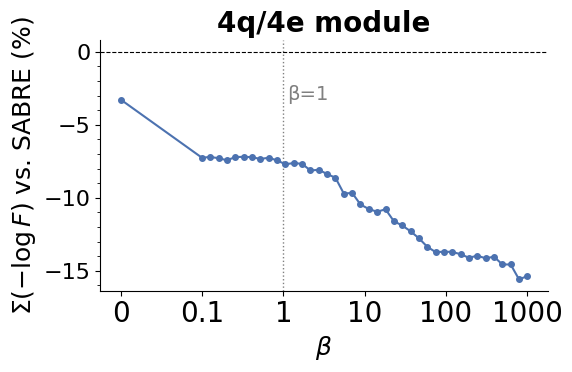

Saved → figures/fig_v2_beta_grid_square_ring.pdf


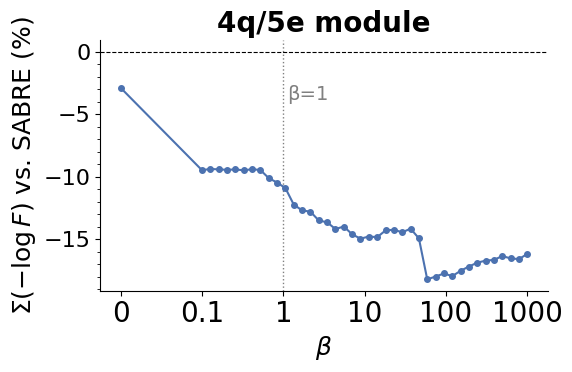

Saved → figures/fig_v2_beta_grid_square_ring_diag.pdf


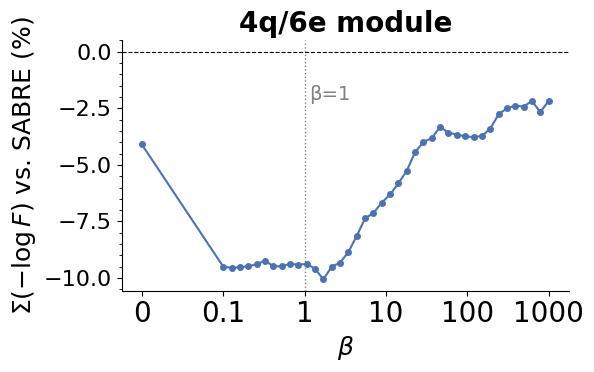

Saved → figures/fig_v2_beta_grid_square_ring_full.pdf


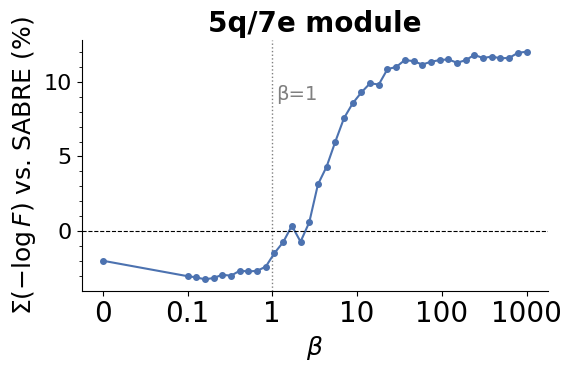

Saved → figures/fig_v2_beta_grid_pentagon_ring.pdf


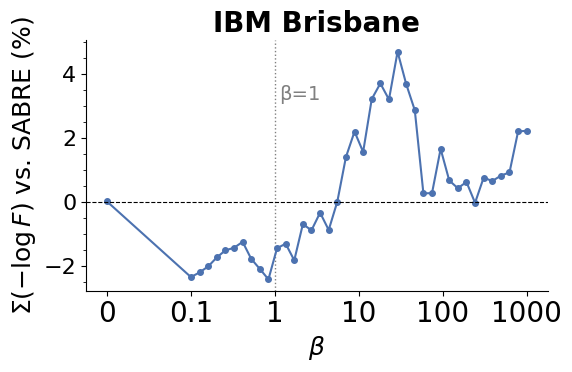

Saved → figures/fig_v2_beta_grid_fake_brisbane.pdf


In [2]:
# ── Beta grid search: justifying β=1 default ──────────────────────────────────

dg  = pd.read_csv('Results/grid_snail.csv')
dgi = pd.read_csv('Results/grid_ibm.csv')

def avg_pct_vs_sabre(df, device=None):
    """Mean lf_cost over all seeds for each β, expressed as % change vs SABRE mean."""
    if device is not None:
        df = df[df.device == device]
    beta_order = sorted(df[(df.router == 'FINESSE') & (df.alpha == 1.0)]['beta'].dropna().unique())
    sabre_mean = (df[df.router == 'SABRE']
                  .groupby(['device', 'circuit'])['lf_cost'].mean())
    finesse_mean = (df[(df.router == 'FINESSE') & (df.alpha == 1.0)]
                    .groupby(['device', 'circuit', 'beta'])['lf_cost'].mean())
    pcts = []
    for b in beta_order:
        try:
            fm = finesse_mean.xs(b, level='beta')
        except KeyError:
            pcts.append(np.nan)
            continue
        common = fm.index.intersection(sabre_mean.index)
        pcts.append((100 * (fm[common] - sabre_mean[common]) / sabre_mean[common]).mean())
    return beta_order, pcts

SNAIL_DEVICE_ORDER = ['square_ring', 'square_ring_diag', 'square_ring_full', 'pentagon_ring']
PANEL_TITLES = {
    'square_ring':      '4q/4e module',
    'square_ring_diag': '4q/5e module',
    'square_ring_full': '4q/6e module',
    'pentagon_ring':    '5q/7e module',
    'fake_brisbane':    'IBM Brisbane',
}

panels = []
for dev in SNAIL_DEVICE_ORDER:
    if dev in dg['device'].values:
        betas, pcts = avg_pct_vs_sabre(dg, device=dev)
        panels.append((dev, betas, pcts))
betas_i, pcts_i = avg_pct_vs_sabre(dgi)
panels.append(('fake_brisbane', betas_i, pcts_i))

# ── Plot ──────────────────────────────────────────────────────────────────────
def beta_to_x(b):
    if b == 0.0:
        return -1.0
    return np.log10(b) - np.log10(0.1)

xtick_vals = [0.0, 0.1, 1.0, 10.0, 100.0, 1000.0]
xtick_pos  = [beta_to_x(b) for b in xtick_vals]
xtick_lbl  = ['0', '0.1', '1', '10', '100', '1000']
x1 = beta_to_x(1.0)

for dev, betas, pcts in panels:
    fig, ax = plt.subplots(figsize=(6, 4))
    xs = [beta_to_x(b) for b in betas]
    ax.plot(xs, pcts, 'o-', color='#4C72B0', markersize=4)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(x1, color='grey', linewidth=1.0, linestyle=':', zorder=1)
    ax.text(x1 + 0.05, 0.82, 'β=1', transform=ax.get_xaxis_transform(),
            fontsize=14, color='grey', ha='left', va='top')
    ax.set_xticks(xtick_pos)
    ax.set_xticklabels(xtick_lbl)
    ax.set_xlabel(r'$\beta$')
    ax.set_ylabel(r'$\Sigma({-}\log F)$ vs. SABRE (%)')
    ax.set_title(PANEL_TITLES[dev], fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    plt.tight_layout()
    fname = f'figures/fig_v2_beta_grid_{dev}.pdf'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'Saved → {fname}')

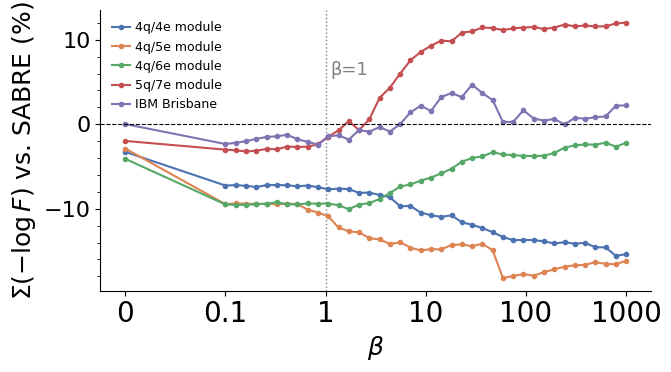

Saved → figures/fig_v2_beta_grid_all.pdf


In [3]:
# ── Beta grid: all devices on one plot ────────────────────────────────────────

DEVICE_COLORS = {
    'square_ring':      '#4C72B0',
    'square_ring_diag': '#DD8452',
    'square_ring_full': '#55A868',
    'pentagon_ring':    '#C44E52',
    'fake_brisbane':    '#8172B2',
}

fig, ax = plt.subplots(figsize=(7, 4))

for dev, betas, pcts in panels:
    xs = [beta_to_x(b) for b in betas]
    ax.plot(xs, pcts, 'o-', color=DEVICE_COLORS[dev],
            markersize=3, linewidth=1.5, label=PANEL_TITLES[dev])

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(x1, color='grey', linewidth=1.0, linestyle=':', zorder=1)
ax.text(x1 + 0.05, 0.82, 'β=1', transform=ax.get_xaxis_transform(),
        fontsize=13, color='grey', ha='left', va='top')
ax.set_xticks(xtick_pos)
ax.set_xticklabels(xtick_lbl)
ax.set_xlabel(r'$\beta$')
ax.set_ylabel(r'$\Sigma({-}\log F)$ vs. SABRE (%)')
ax.legend(frameon=False, fontsize=9, handlelength=1.5, handletextpad=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())

plt.tight_layout()
fname = 'figures/fig_v2_beta_grid_all.pdf'
plt.savefig(fname, bbox_inches='tight')
plt.show()
print(f'Saved → {fname}')

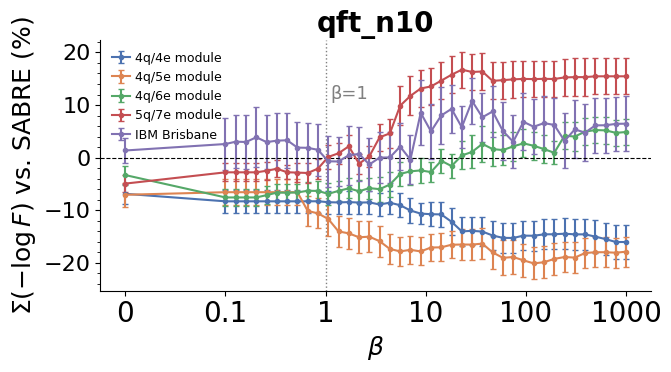

Saved → figures/fig_v2_beta_grid_circ_qft_n10.pdf


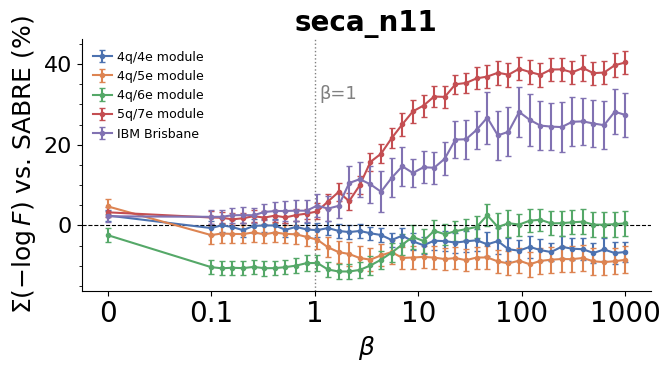

Saved → figures/fig_v2_beta_grid_circ_seca_n11.pdf


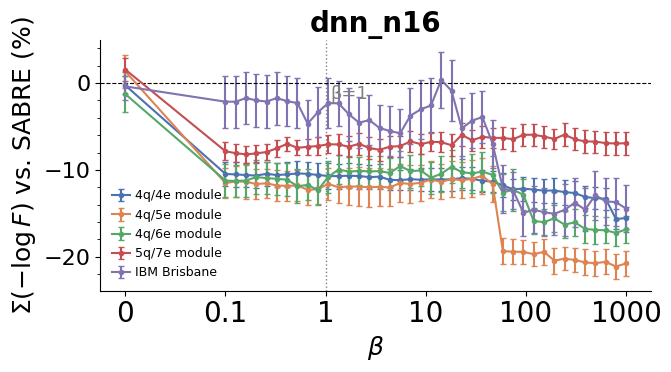

Saved → figures/fig_v2_beta_grid_circ_dnn_n16.pdf


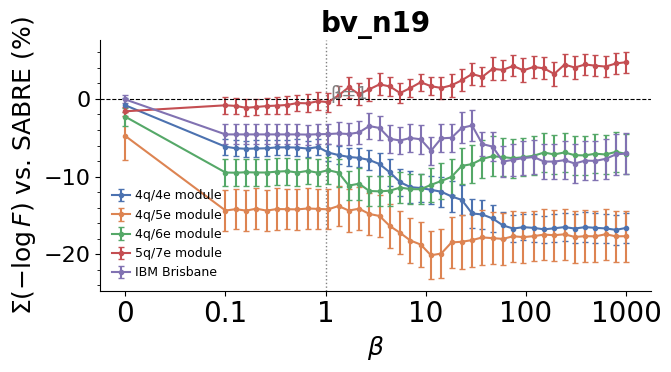

Saved → figures/fig_v2_beta_grid_circ_bv_n19.pdf


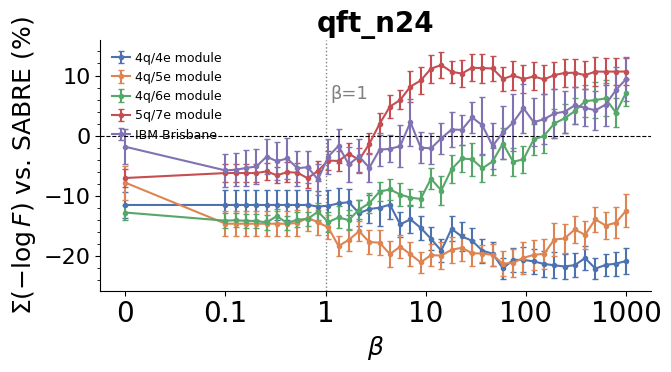

Saved → figures/fig_v2_beta_grid_circ_qft_n24.pdf


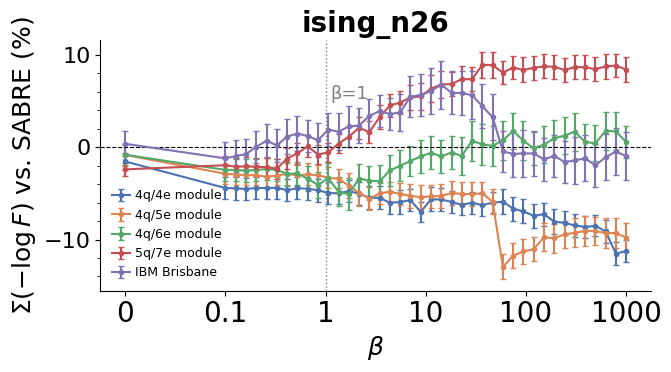

Saved → figures/fig_v2_beta_grid_circ_ising_n26.pdf


In [4]:
# ── Per-circuit beta sweep: all devices, with seed error bars ─────────────────

def pct_with_err(df, device, circuit):
    """Per-seed % change vs SABRE; returns (betas, means, stderr over seeds)."""
    df = df[(df.device == device) & (df.circuit == circuit)]
    beta_order = sorted(df[(df.router == 'FINESSE') & (df.alpha == 1.0)]['beta'].dropna().unique())
    sabre   = df[df.router == 'SABRE'].set_index('seed')['lf_cost']
    finesse = (df[(df.router == 'FINESSE') & (df.alpha == 1.0)]
               .set_index(['beta', 'seed'])['lf_cost'])
    means, errs = [], []
    for b in beta_order:
        try:
            fm = finesse.xs(b, level='beta')
        except KeyError:
            means.append(np.nan); errs.append(np.nan); continue
        common = fm.index.intersection(sabre.index)
        if len(common) == 0:
            means.append(np.nan); errs.append(np.nan); continue
        pct = 100 * (fm[common] - sabre[common]) / sabre[common]
        means.append(pct.mean())
        errs.append(pct.std() / np.sqrt(len(pct)))
    return beta_order, means, errs

all_circuits = [c for c in
    ['qft_n10', 'seca_n11', 'dnn_n16', 'bv_n19', 'qft_n24', 'ising_n26']
    if c in dg['circuit'].values or c in dgi['circuit'].values]

for circ in all_circuits:
    fig, ax = plt.subplots(figsize=(7, 4))
    for dev, _, _ in panels:
        df_src = dgi if dev == 'fake_brisbane' else dg
        if circ not in df_src['circuit'].values:
            continue
        betas, means, errs = pct_with_err(df_src, device=dev, circuit=circ)
        xs = [beta_to_x(b) for b in betas]
        ax.errorbar(xs, means, yerr=errs, fmt='o-', color=DEVICE_COLORS[dev],
                    markersize=3, linewidth=1.5, capsize=2, label=PANEL_TITLES[dev])

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(x1, color='grey', linewidth=1.0, linestyle=':', zorder=1)
    ax.text(x1 + 0.05, 0.82, 'β=1', transform=ax.get_xaxis_transform(),
            fontsize=13, color='grey', ha='left', va='top')
    ax.set_xticks(xtick_pos)
    ax.set_xticklabels(xtick_lbl)
    ax.set_xlabel(r'$\beta$')
    ax.set_ylabel(r'$\Sigma({-}\log F)$ vs. SABRE (%)')
    ax.set_title(circ, fontweight='bold')
    ax.legend(frameon=False, fontsize=9, handlelength=1.5, handletextpad=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    plt.tight_layout()
    fname = f'figures/fig_v2_beta_grid_circ_{circ}.pdf'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'Saved → {fname}')

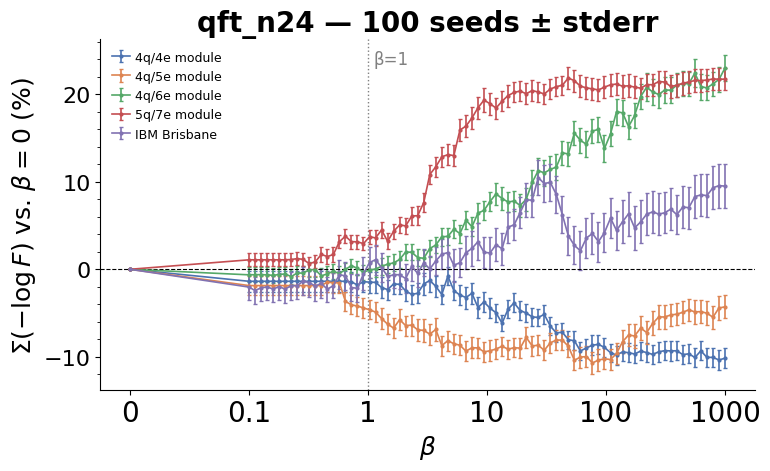

Saved → figures/fig_dense_beta_qft_n24.pdf


In [5]:
# ── Dense beta sweep: qft_n24, all devices, error bars over seeds ─────────────
# Baseline: FINESSE β=0 (hop-count only). Isolates the gain from fidelity weighting.
# Requires: Results/dense_snail.csv and Results/dense_ibm.csv
# Run on server: ./run_parallel.sh dense 100 && ./run_parallel.sh dense --ibm 100

dd_s = pd.read_csv('Results/dense_snail.csv')
dd_i = pd.read_csv('Results/dense_ibm.csv')

def dense_pct_vs_beta0(df, device):
    df = df[df.device == device]
    finesse = (df[(df.router == 'FINESSE') & (df.alpha == 1.0)]
               .set_index(['beta', 'seed'])['lf_cost'])
    try:
        base = finesse.xs(0.0, level='beta')   # β=0 per seed
    except KeyError:
        return [], [], []
    beta_order = sorted(finesse.index.get_level_values('beta').unique())
    means, errs = [], []
    for b in beta_order:
        try:
            fm = finesse.xs(b, level='beta')
        except KeyError:
            means.append(np.nan); errs.append(np.nan); continue
        common = fm.index.intersection(base.index)
        if len(common) == 0:
            means.append(np.nan); errs.append(np.nan); continue
        pct = 100 * (fm[common] - base[common]) / base[common]
        means.append(pct.mean())
        errs.append(pct.std() / np.sqrt(len(pct)))
    return beta_order, means, errs

fig, ax = plt.subplots(figsize=(8, 5))

for dev in SNAIL_DEVICE_ORDER:
    if dev not in dd_s['device'].values:
        continue
    betas, means, errs = dense_pct_vs_beta0(dd_s, dev)
    xs = [beta_to_x(b) for b in betas]
    ax.errorbar(xs, means, yerr=errs, fmt='o-', color=DEVICE_COLORS[dev],
                markersize=2, linewidth=1.2, capsize=1.5, label=PANEL_TITLES[dev])

if 'fake_brisbane' in dd_i['device'].values:
    betas, means, errs = dense_pct_vs_beta0(dd_i, 'fake_brisbane')
    xs = [beta_to_x(b) for b in betas]
    ax.errorbar(xs, means, yerr=errs, fmt='o-', color=DEVICE_COLORS['fake_brisbane'],
                markersize=2, linewidth=1.2, capsize=1.5, label=PANEL_TITLES['fake_brisbane'])

n_seeds = dd_s['seed'].nunique()
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(x1, color='grey', linewidth=1.0, linestyle=':', zorder=1)
ax.text(x1 + 0.05, 0.97, 'β=1', transform=ax.get_xaxis_transform(),
        fontsize=12, color='grey', ha='left', va='top')
ax.set_xticks(xtick_pos)
ax.set_xticklabels(xtick_lbl)
ax.set_xlabel(r'$\beta$')
ax.set_ylabel(r'$\Sigma({-}\log F)$ vs. $\beta{=}0$ (%)')
ax.set_title(f'qft_n24 — {n_seeds} seeds ± stderr', fontweight='bold')
ax.legend(frameon=False, fontsize=9, handlelength=1.5, handletextpad=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())

plt.tight_layout()
fname = 'figures/fig_dense_beta_qft_n24.pdf'
plt.savefig(fname, bbox_inches='tight')
plt.show()
print(f'Saved → {fname}')

### β grid discussion

β=1 is best or near-best across all SNAIL topologies and both post-selection modes. High β (≥10) over-weights fidelity at the expense of hop count, hurting circuits on pentagon_ring where path length variation is larger. Pure fidelity (α=0, β=1) loses directional routing signal on large circuits. β=1 is therefore the chosen default.

**Equivalence note:** The 24-seed paper runs used `fidelity_blend=0.5` in the old parameterisation, which gives D′ = 0.5·D_hop + 0.5·D_fid. The new parameterisation with α=1, β=1 gives D′ = D_hop + D_fid. Only the ratio α/β matters for routing decisions (argmin is scale-invariant), so these are identical 

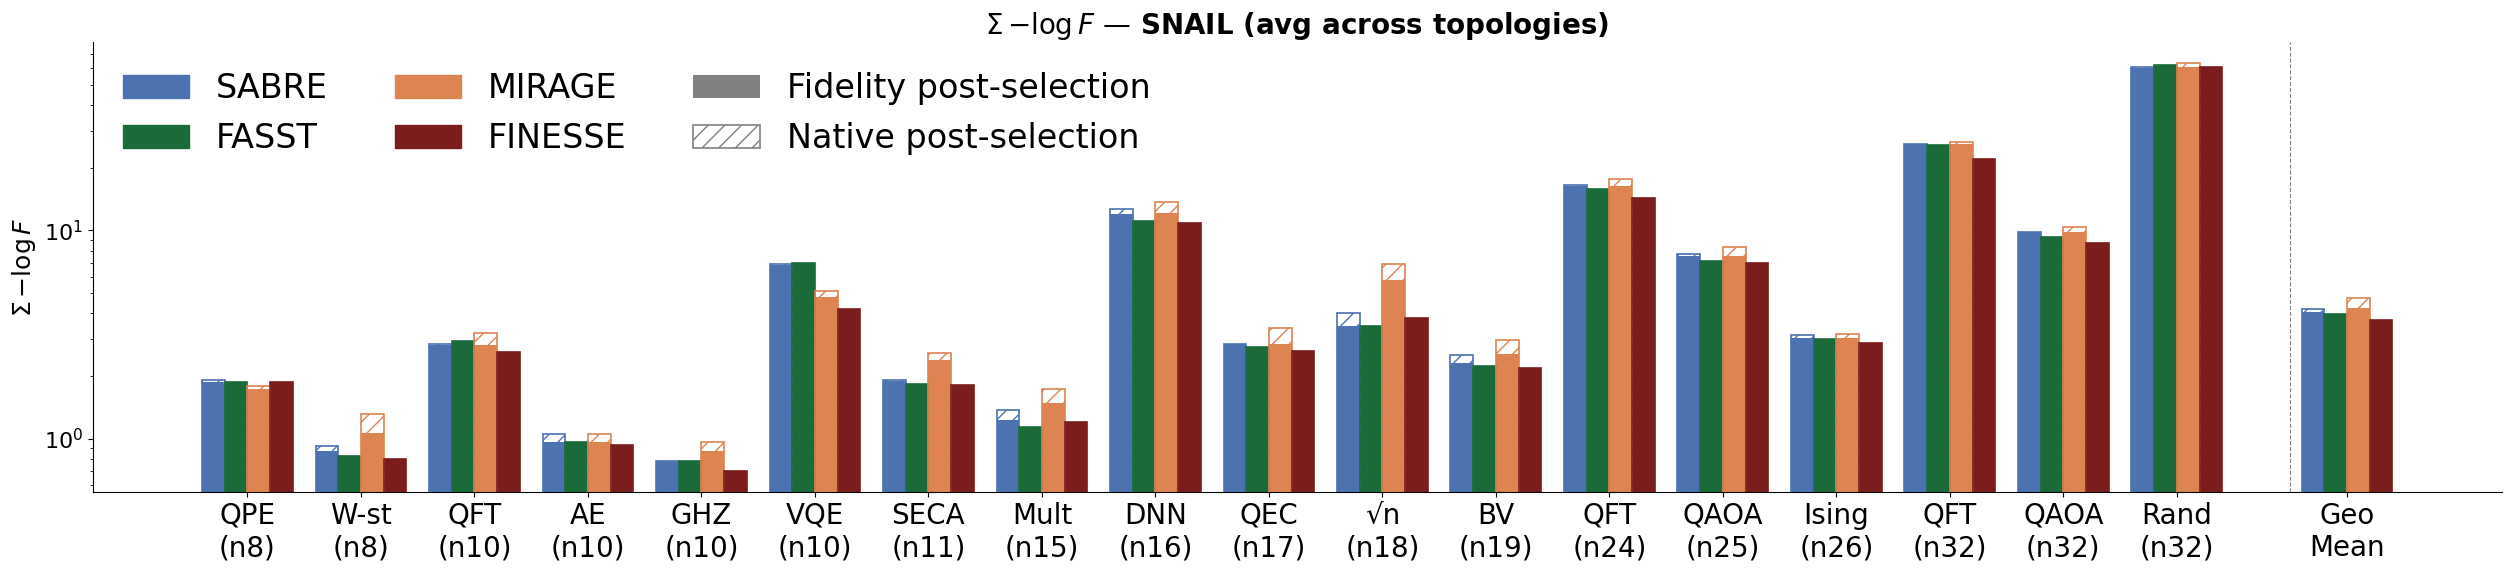

Saved → figures/fig_v2_snail_lf_cost_per_circ.pdf


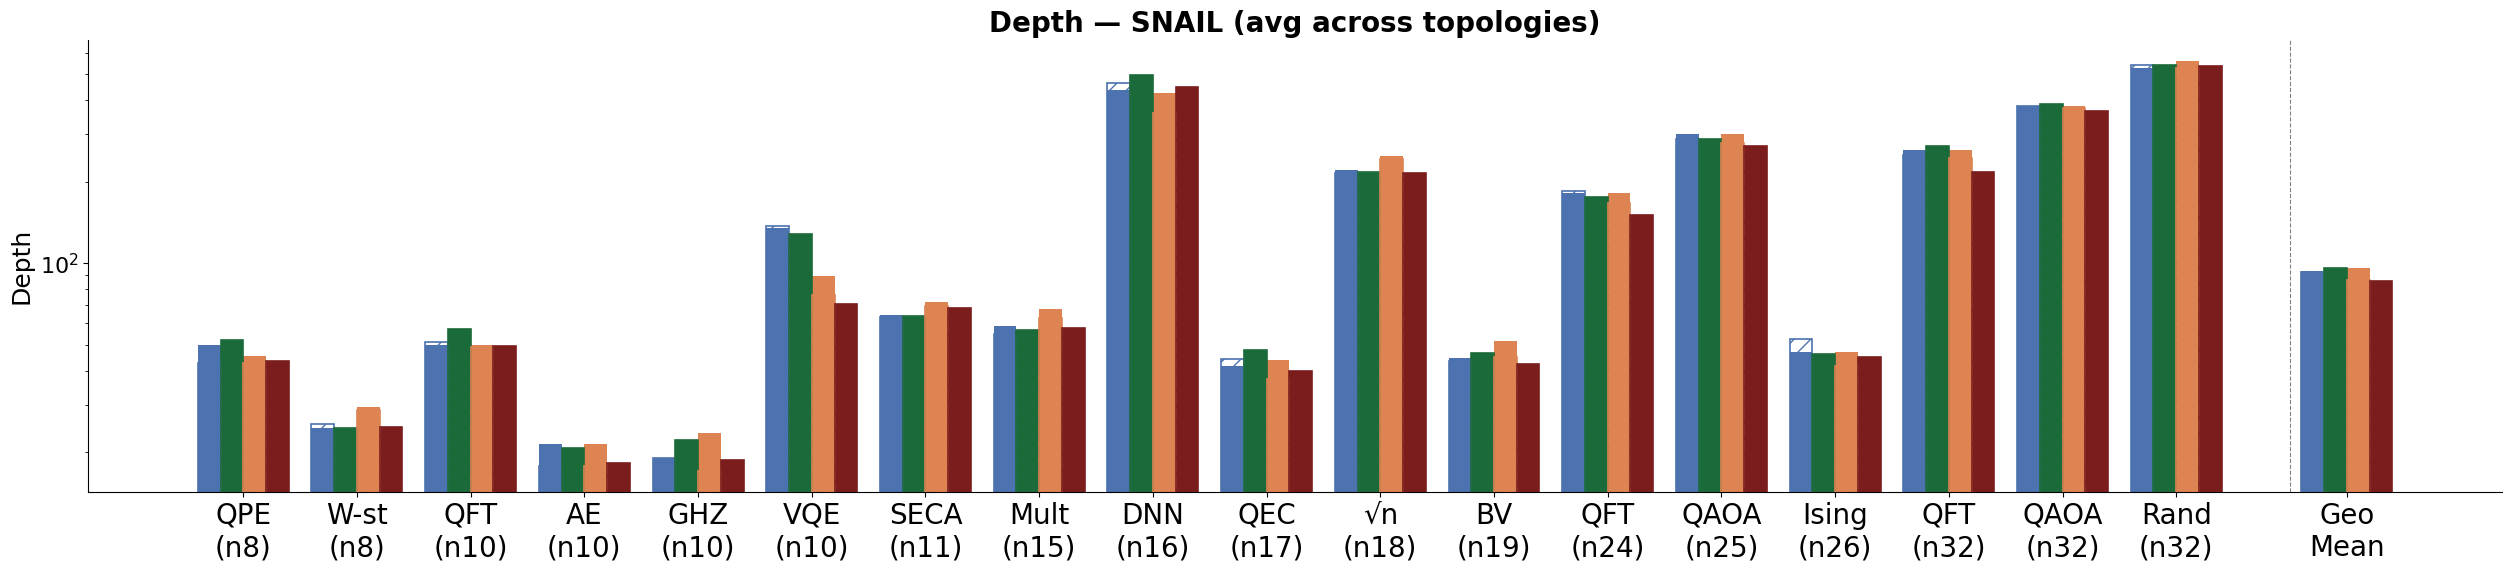

Saved → figures/fig_v2_snail_depth_per_circ.pdf


In [6]:
# ── Per-circuit absolute values — SNAIL averaged across topologies ─────────────
import matplotlib.patches as mpatches

METRICS = [
    ('lf_cost', r'$\Sigma\,{-}\log F$'),
    ('depth',   'Depth'),
]

for col, ylabel in METRICS:
    circs = [c for c in CIRCUIT_ORDER if c in ps_snail_nat['circuit'].values]
    n_circ = len(circs)
    xs     = np.arange(n_circ)
    mean_x = n_circ + 0.5          # gap before mean bar
    n_cfg  = len(CONFIG_ORDER)
    w      = 0.80 / n_cfg

    fig, ax = plt.subplots(figsize=(max(13, n_circ*1.3 + 2), 6))
    ax.set_title(f'{ylabel} — SNAIL (avg across topologies)', fontweight='bold')

    for k, (cfg, color) in enumerate(zip(CONFIG_ORDER, CFG_COLORS)):
        x_pos  = xs + (k - (n_cfg-1)/2)*w
        x_mean = mean_x + (k - (n_cfg-1)/2)*w

        def topo_avg(ps, cfg=cfg, col=col):
            vals = []
            for circ in circs:
                tv = [float(ps[(ps.topo==t)&(ps.circuit==circ)&(ps.config==cfg)][col].values[0])
                      for t in nowrap_topos
                      if len(ps[(ps.topo==t)&(ps.circuit==circ)&(ps.config==cfg)])]
                vals.append(np.mean(tv) if tv else np.nan)
            return np.array(vals)

        vals_lf  = topo_avg(ps_snail_lf)
        vals_nat = topo_avg(ps_snail_nat)

        ax.bar(x_pos, vals_lf,  w, color=color, zorder=2)
        ax.bar(x_pos, vals_nat, w, facecolor='none', edgecolor=color,
               linewidth=1.2, hatch='//', zorder=3)

        gm_lf  = np.exp(np.nanmean(np.log(vals_lf[vals_lf  > 0])))
        gm_nat = np.exp(np.nanmean(np.log(vals_nat[vals_nat > 0])))
        ax.bar(x_mean, gm_lf,  w, color=color, zorder=2)
        ax.bar(x_mean, gm_nat, w, facecolor='none', edgecolor=color,
               linewidth=1.2, hatch='//', zorder=3)

    ax.axvline(n_circ, color='grey', linewidth=0.8, linestyle='--', zorder=1)
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(mticker.LogFormatterSciNotation(labelOnlyBase=False))
    ax.yaxis.set_minor_locator(mticker.LogLocator(subs='auto'))

    all_xticks = list(xs) + [mean_x]
    all_labels = [CIRC_LABELS.get(c, c) for c in circs] + ['Geo\nMean']
    ax.set_xticks(all_xticks)
    ax.set_xticklabels(all_labels)
    ax.set_ylabel(ylabel)

    if col == 'lf_cost':
        cfg_handles = [mpatches.Patch(color=c, label=cfg)
                       for cfg, c in zip(CONFIG_ORDER, CFG_COLORS)]
        ps_handles  = [mpatches.Patch(facecolor='grey', label='Fidelity post-selection'),
                       mpatches.Patch(facecolor='none', edgecolor='grey', linewidth=1.2,
                                      hatch='//', label='Native post-selection')]
        ax.legend(handles=cfg_handles + ps_handles, frameon=False, ncol=3, loc='upper left')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    fname = f'figures/fig_v2_snail_{col}_per_circ.pdf'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'Saved → {fname}')

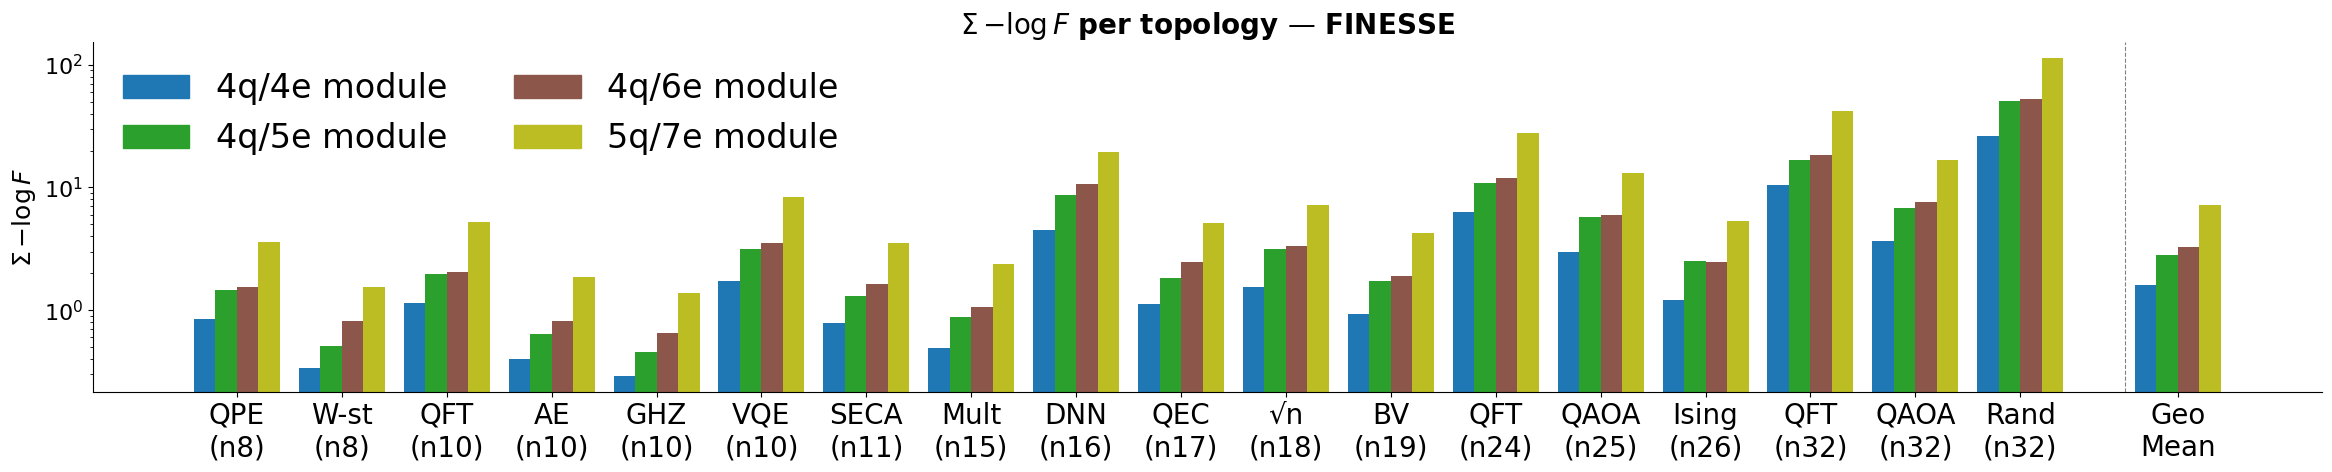

Saved → figures/fig_v2_snail_lf_cost_by_topo.pdf


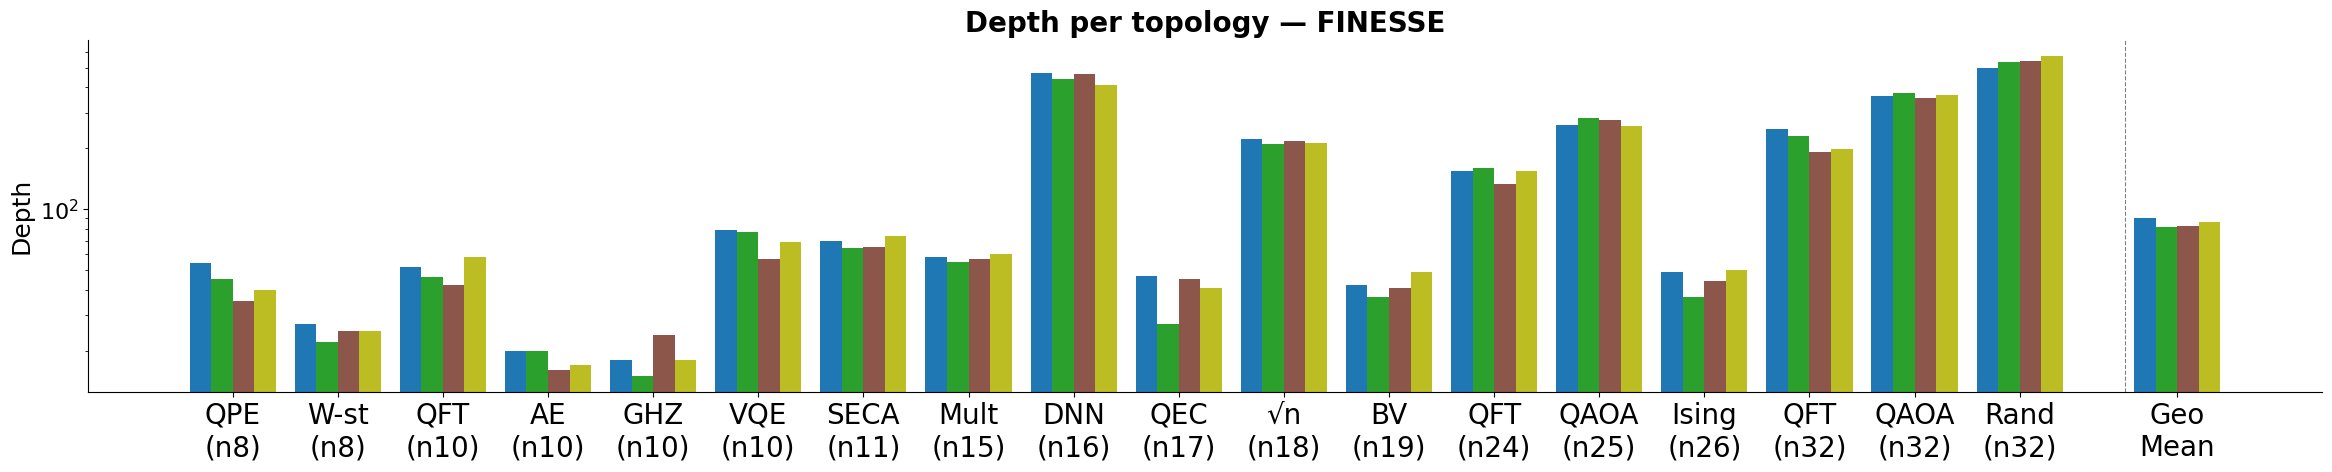

Saved → figures/fig_v2_snail_depth_by_topo.pdf


In [7]:
# ── SNAIL by-topology: FINESSE, topologies as bar groups ──────────────────────
import matplotlib.patches as mpatches

METRICS = [
    ('lf_cost', r'$\Sigma\,{-}\log F$'),
    ('depth',   'Depth'),
]

topo_colors = plt.cm.tab10(np.linspace(0, 0.8, len(nowrap_topos)))
n_t = len(nowrap_topos)
w   = 0.82 / n_t

for col, ylabel in METRICS:
    fin_lf  = ps_snail_lf[ps_snail_lf['config'] == 'FINESSE']
    circs   = [c for c in CIRCUIT_ORDER if c in fin_lf['circuit'].values]
    n_circ  = len(circs)
    xs      = np.arange(n_circ)
    mean_x  = n_circ + 0.5

    fig, ax = plt.subplots(figsize=(max(10, n_circ*1.2 + 2), 5))
    ax.set_title(f'{ylabel} per topology — FINESSE', fontweight='bold')

    for k, (topo, color) in enumerate(zip(nowrap_topos, topo_colors)):
        x_pos  = xs + (k - (n_t-1)/2)*w
        x_mean = mean_x + (k - (n_t-1)/2)*w

        vals = np.array([
            float(fin_lf[(fin_lf.topo==topo)&(fin_lf.circuit==c)][col].values[0])
            if len(fin_lf[(fin_lf.topo==topo)&(fin_lf.circuit==c)]) else np.nan
            for c in circs
        ])
        ax.bar(x_pos, vals, w, color=color, zorder=2)

        gm = np.exp(np.nanmean(np.log(vals[vals > 0])))
        ax.bar(x_mean, gm, w, color=color, zorder=2)

    ax.axvline(n_circ, color='grey', linewidth=0.8, linestyle='--', zorder=1)
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(mticker.LogFormatterSciNotation(labelOnlyBase=False))
    ax.yaxis.set_minor_locator(mticker.LogLocator(subs='auto'))

    all_xticks = list(xs) + [mean_x]
    all_labels = [CIRC_LABELS.get(c, c) for c in circs] + ['Geo\nMean']
    ax.set_xticks(all_xticks)
    ax.set_xticklabels(all_labels)
    ax.set_ylabel(ylabel)

    if col == 'lf_cost':
        topo_handles = [mpatches.Patch(color=topo_colors[i], label=TOPO_LABELS.get(t, t))
                        for i, t in enumerate(nowrap_topos)]
        ax.legend(handles=topo_handles, frameon=False, ncol=2, loc='upper left')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    fname = f'figures/fig_v2_snail_{col}_by_topo.pdf'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'Saved → {fname}')

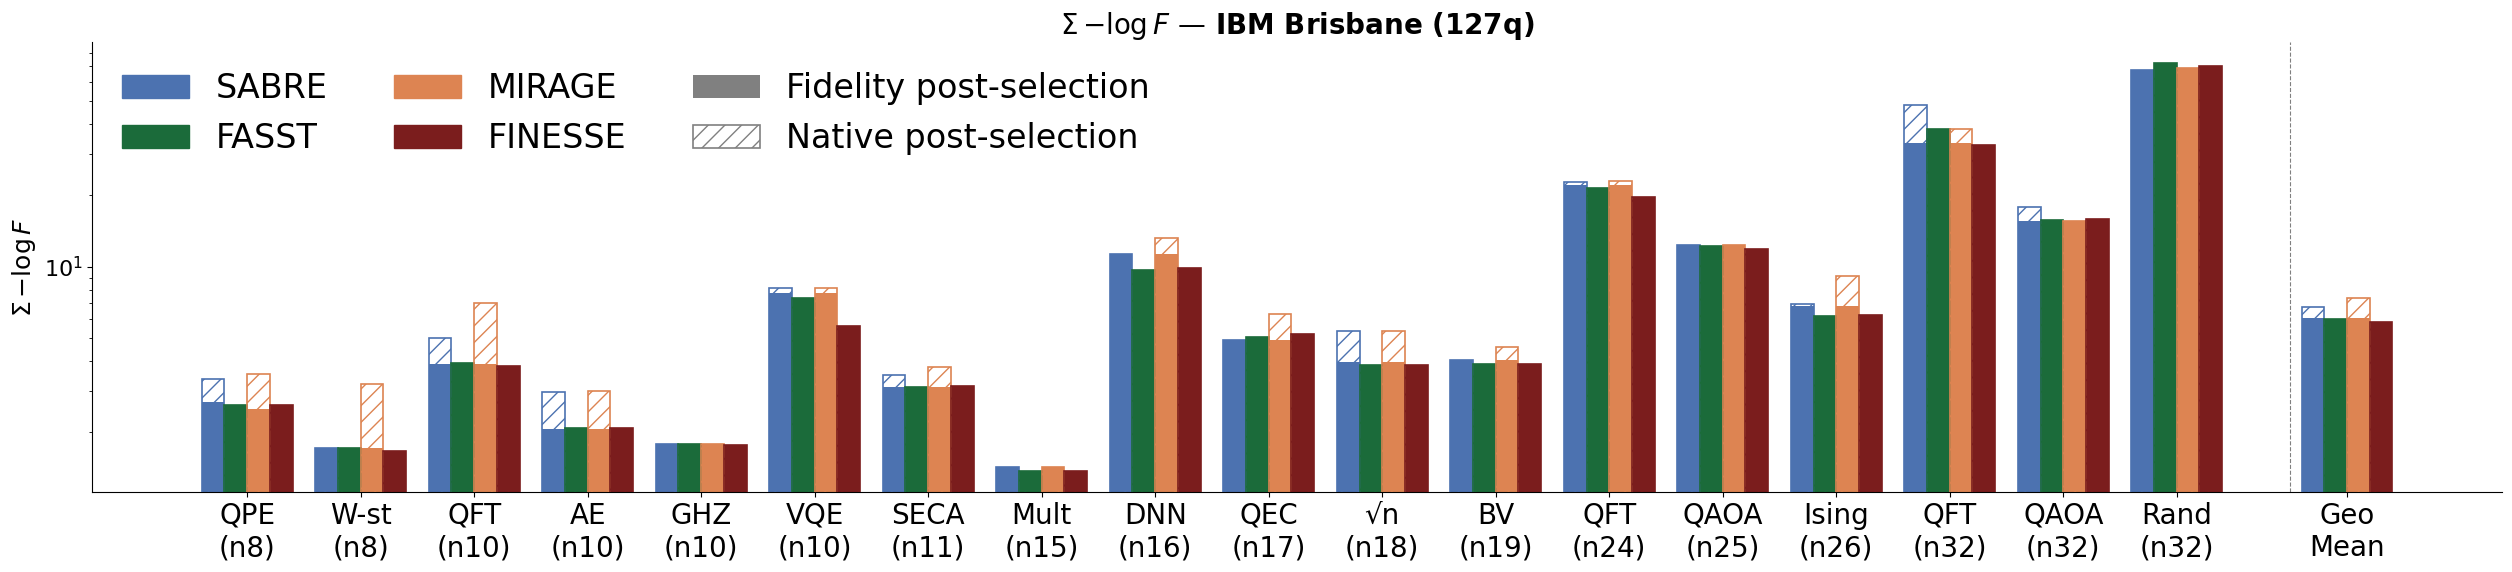

Saved → figures/fig_v2_ibm_lf_cost.pdf


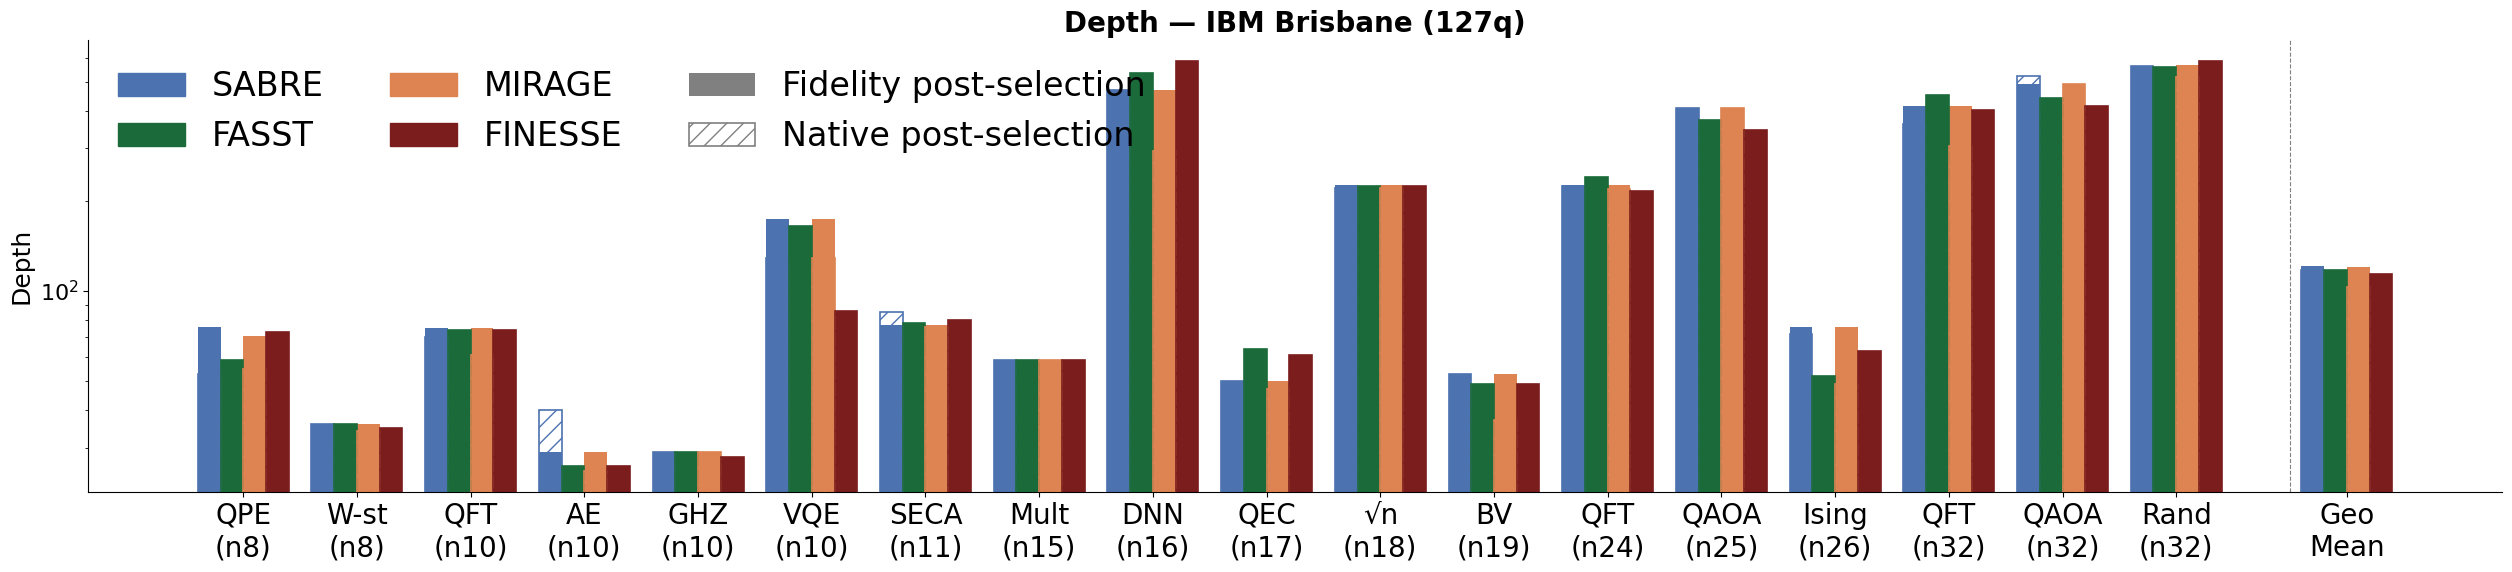

Saved → figures/fig_v2_ibm_depth.pdf


In [8]:
# ── IBM Brisbane: lf_cost + depth, both PS methods overlaid ──────────────────
import matplotlib.patches as mpatches

METRICS = [
    ('lf_cost', r'$\Sigma\,{-}\log F$'),
    ('depth',   'Depth'),
]

for col, ylabel in METRICS:
    circs_ibm = [c for c in CIRCUIT_ORDER if c in ps_ibm_nat['circuit'].values]
    n_circ = len(circs_ibm)
    xs     = np.arange(n_circ)
    mean_x = n_circ + 0.5
    n_cfg  = len(CONFIG_ORDER)
    w      = 0.80 / n_cfg

    fig, ax = plt.subplots(figsize=(max(13, n_circ*1.3 + 2), 6))
    ax.set_title(f'{ylabel} — IBM Brisbane (127q)', fontweight='bold')

    for k, (cfg, color) in enumerate(zip(CONFIG_ORDER, CFG_COLORS)):
        x_pos  = xs + (k - (n_cfg-1)/2)*w
        x_mean = mean_x + (k - (n_cfg-1)/2)*w

        def ibm_vals(ps, cfg=cfg, col=col):
            return np.array([
                float(ps[(ps.circuit==c)&(ps.config==cfg)][col].values[0])
                if len(ps[(ps.circuit==c)&(ps.config==cfg)]) else np.nan
                for c in circs_ibm
            ])

        vals_lf  = ibm_vals(ps_ibm_lf)
        vals_nat = ibm_vals(ps_ibm_nat)

        ax.bar(x_pos, vals_lf,  w, color=color, zorder=2)
        ax.bar(x_pos, vals_nat, w, facecolor='none', edgecolor=color,
               linewidth=1.2, hatch='//', zorder=3)

        gm_lf  = np.exp(np.nanmean(np.log(vals_lf[vals_lf   > 0])))
        gm_nat = np.exp(np.nanmean(np.log(vals_nat[vals_nat  > 0])))
        ax.bar(x_mean, gm_lf,  w, color=color, zorder=2)
        ax.bar(x_mean, gm_nat, w, facecolor='none', edgecolor=color,
               linewidth=1.2, hatch='//', zorder=3)

    ax.axvline(n_circ, color='grey', linewidth=0.8, linestyle='--', zorder=1)
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(mticker.LogFormatterSciNotation(labelOnlyBase=False))
    ax.yaxis.set_minor_locator(mticker.LogLocator(subs='auto'))

    all_xticks = list(xs) + [mean_x]
    all_labels = [CIRC_LABELS.get(c, c) for c in circs_ibm] + ['Geo\nMean']
    ax.set_xticks(all_xticks)
    ax.set_xticklabels(all_labels)
    ax.set_ylabel(ylabel)

    cfg_handles = [mpatches.Patch(color=c, label=cfg)
                   for cfg, c in zip(CONFIG_ORDER, CFG_COLORS)]
    ps_handles  = [mpatches.Patch(facecolor='grey', label='Fidelity post-selection'),
                   mpatches.Patch(facecolor='none', edgecolor='grey', linewidth=1.2,
                                  hatch='//', label='Native post-selection')]
    ax.legend(handles=cfg_handles + ps_handles, frameon=False, ncol=3, loc='upper left')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    fname = f'figures/fig_v2_ibm_{col}.pdf'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'Saved → {fname}')

In [2]:
# ── FINESSE_AUTO vs SABRE (transpile run): deployment comparison ───────────────
# SABRE baseline: fidelity post-selected (best lf_cost across 20 seeds).
# FINESSE_AUTO: 1 call, 21 internal β trials, post-selects internally.
# Comparable compute budget (~21 route() calls each).

dt = pd.read_csv('Results/transpile_snail.csv')
dt = dt.drop_duplicates(subset=['device', 'circuit', 'router', 'beta', 'seed'])

sabre_best = (
    dt[dt.router == 'SABRE']
    .loc[dt[dt.router == 'SABRE'].groupby(['device', 'circuit'])['lf_cost'].idxmin()]
    .set_index(['device', 'circuit'])['lf_cost']
)
fa = dt[dt.router == 'FINESSE_AUTO'].set_index(['device', 'circuit'])

# Per (device, circuit) table with chosen β
print(f"{'circuit':22s}  {'device':20s}  {'β chosen':>10}  "
      f"{'FINESSE lf':>10}  {'SABRE lf':>10}  {'Δ%':>7}")
print('-' * 88)
for circ in CIRCUIT_ORDER:
    rows = fa[fa.index.get_level_values('circuit') == circ]
    for (dev, _), row in rows.iterrows():
        sb = sabre_best.get((dev, circ), np.nan)
        pct = 100 * (row.lf_cost - sb) / sb if not np.isnan(sb) else np.nan
        b = row.beta
        beta_str = 'inf' if (isinstance(b, float) and np.isinf(b)) else str(b)
        print(f'{circ:22s}  {dev:20s}  {beta_str:>10}  '
              f'{row.lf_cost:10.3f}  {sb:10.3f}  {pct:+7.1f}%')
    print()

pct_ser = 100 * (fa['lf_cost'] - sabre_best) / sabre_best
avg_pct = pct_ser.reset_index(name='pct').groupby('circuit')['pct'].mean()
print(f'Overall mean (avg over topologies & circuits):  {avg_pct.mean():+.1f}%')
print(f'Overall median:                                 {avg_pct.median():+.1f}%')
print('(vs fidelity post-selected SABRE, best of 20 seeds)')


circuit                 device                  β chosen  FINESSE lf    SABRE lf       Δ%
----------------------------------------------------------------------------------------
qpeexact_n8             square_ring                  inf       0.504       0.557     -9.5%
qpeexact_n8             square_ring_full             0.0       0.851       1.074    -20.8%
qpeexact_n8             square_ring_diag             0.0       0.926       0.919     +0.8%
qpeexact_n8             pentagon_ring               20.0       2.302       2.416     -4.7%

wstate_n8               square_ring                  0.0       0.158       0.112    +41.2%
wstate_n8               square_ring_full           200.0       0.364       0.282    +29.1%
wstate_n8               square_ring_diag             0.0       0.237       0.197    +20.5%
wstate_n8               pentagon_ring                0.0       0.674       0.513    +31.2%

qft_n10                 square_ring                  5.0       0.629       0.792    -20.6%


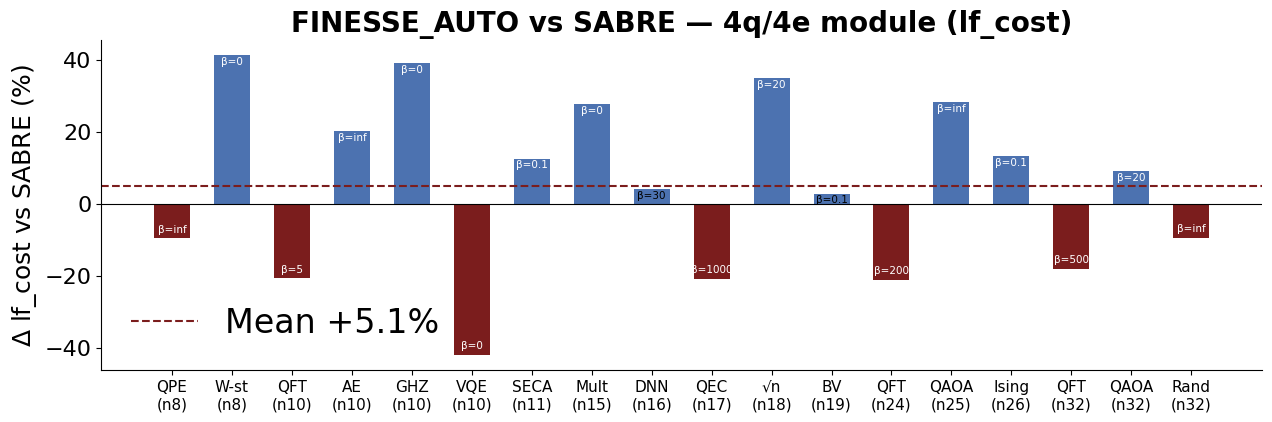

Saved → figures/fig_transpile_lf_cost_square_ring.pdf


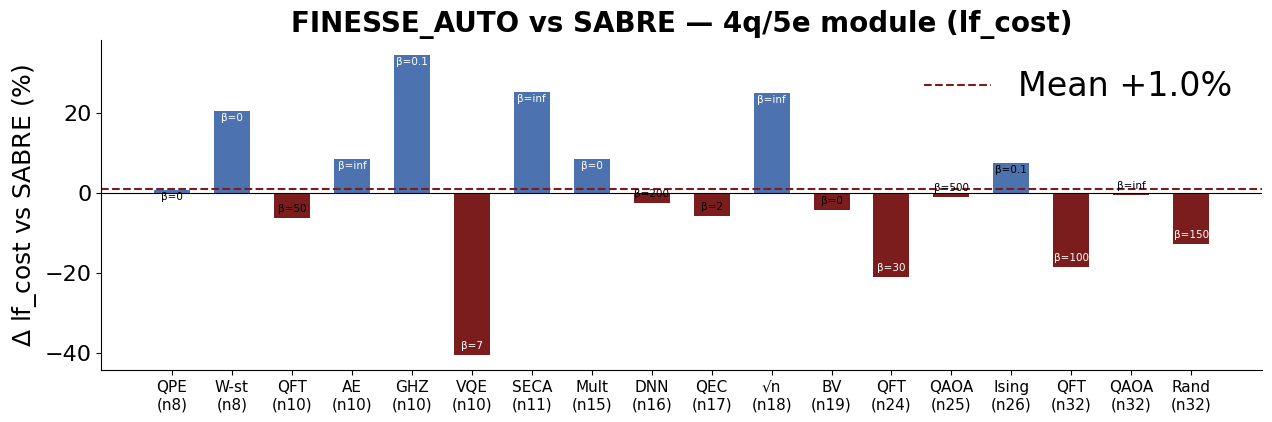

Saved → figures/fig_transpile_lf_cost_square_ring_diag.pdf


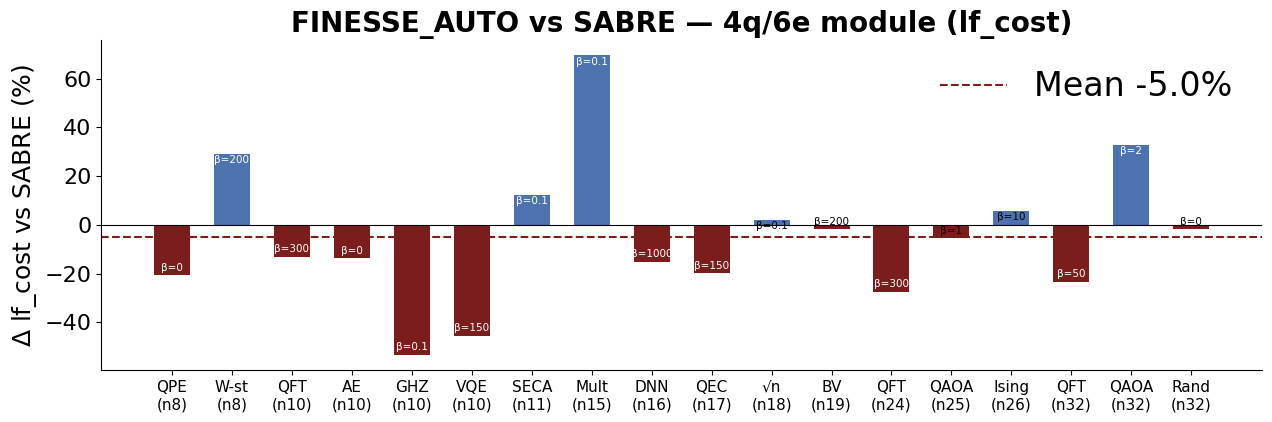

Saved → figures/fig_transpile_lf_cost_square_ring_full.pdf


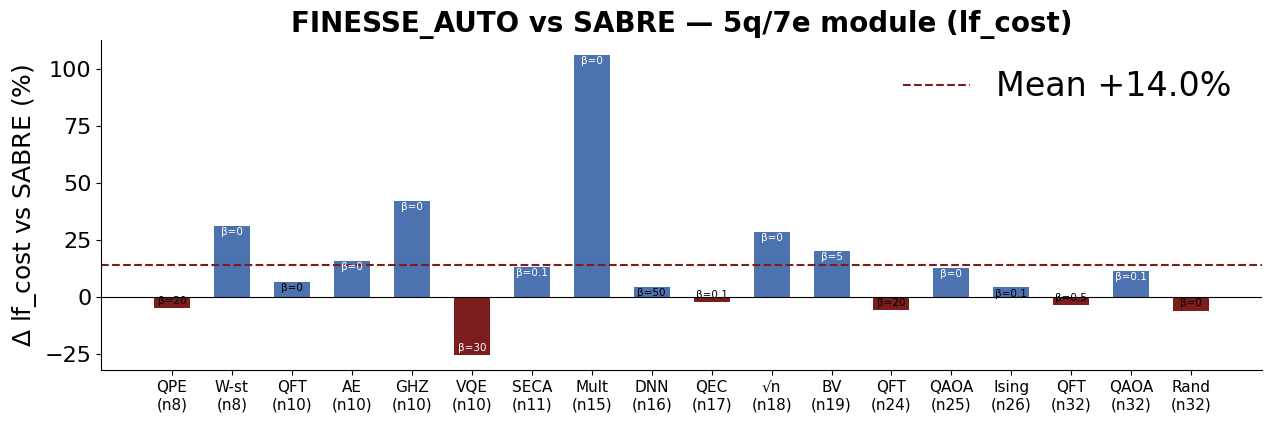

Saved → figures/fig_transpile_lf_cost_pentagon_ring.pdf


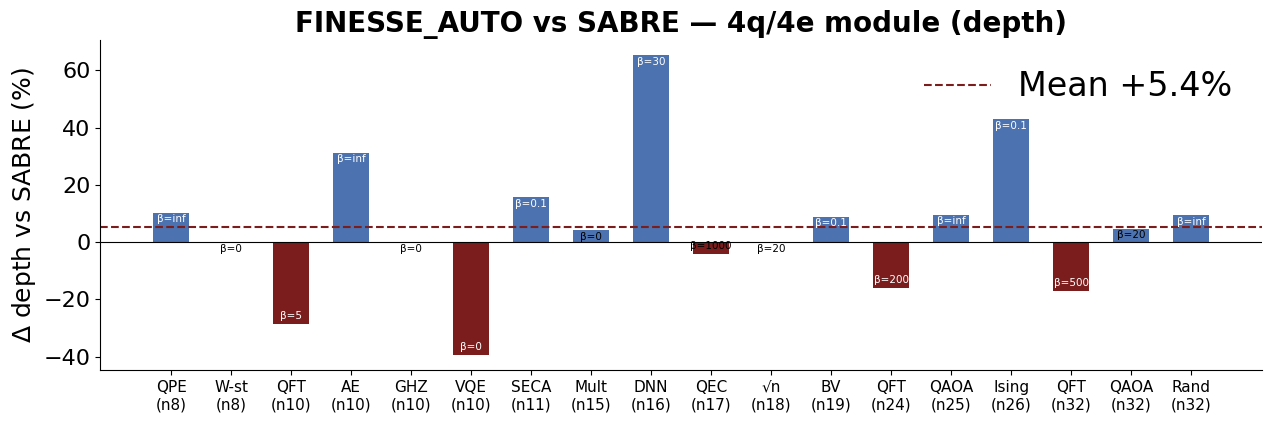

Saved → figures/fig_transpile_depth_square_ring.pdf


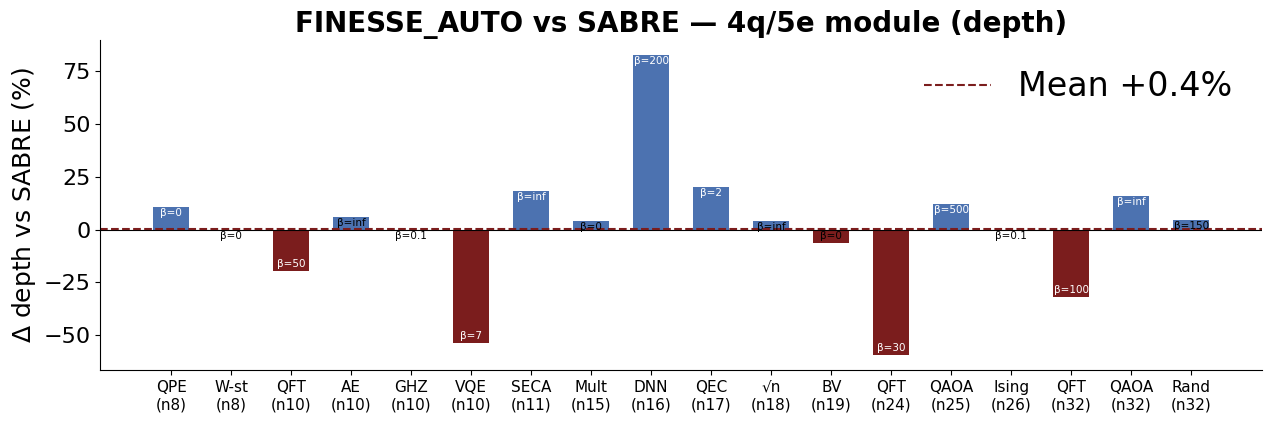

Saved → figures/fig_transpile_depth_square_ring_diag.pdf


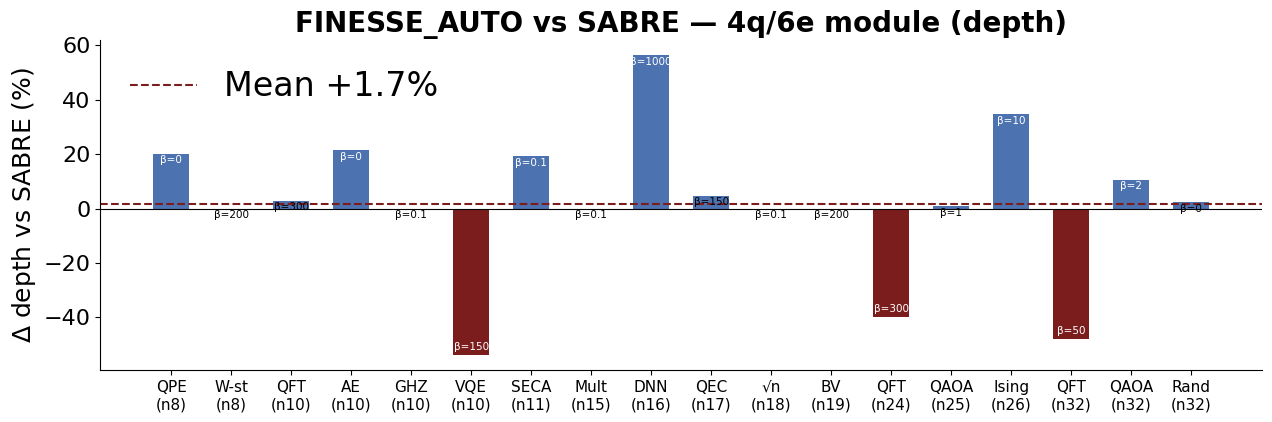

Saved → figures/fig_transpile_depth_square_ring_full.pdf


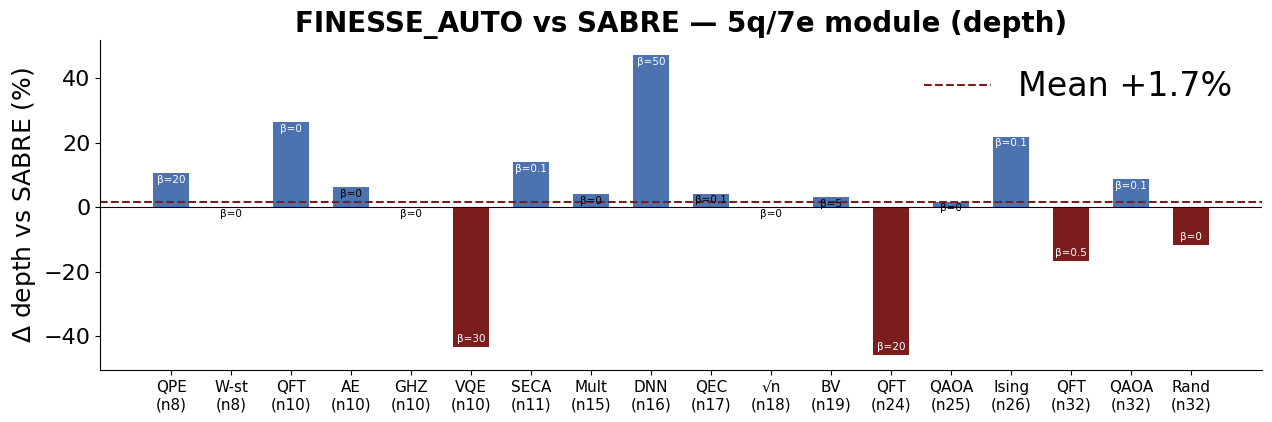

Saved → figures/fig_transpile_depth_pentagon_ring.pdf


In [3]:
# ── Per-device plots: FINESSE_AUTO vs SABRE — lf_cost and depth ─────────────────

DEVICE_ORDER = ['square_ring', 'square_ring_diag', 'square_ring_full', 'pentagon_ring']
DEVICE_LABELS = {
    'square_ring':      '4q/4e module',
    'square_ring_diag': '4q/5e module',
    'square_ring_full': '4q/6e module',
    'pentagon_ring':    '5q/7e module',
}

METRICS = [
    ('lf_cost', 'lf_cost', r'$\Delta$ lf_cost vs SABRE (%)'),
    ('depth',   'depth',   r'$\Delta$ depth vs SABRE (%)'),
]

for metric, sabre_col, ylabel in METRICS:
    # Post-select SABRE by the metric being compared
    sabre_best_m = (
        dt[dt.router == 'SABRE']
        .loc[dt[dt.router == 'SABRE'].groupby(['device', 'circuit'])[sabre_col].idxmin()]
        .set_index(['device', 'circuit'])
    )

    for dev in DEVICE_ORDER:
        dev_fa = fa[fa.index.get_level_values('device') == dev]
        dev_sb = sabre_best_m[sabre_best_m.index.get_level_values('device') == dev]

        circs_dev = [c for c in CIRCUIT_ORDER
                     if (dev, c) in fa.index and (dev, c) in dev_sb.index]
        vals  = [100 * (dev_fa.loc[(dev, c), metric] - dev_sb.loc[(dev, c), metric])
                  / dev_sb.loc[(dev, c), metric] for c in circs_dev]
        betas = [dev_fa.loc[(dev, c), 'beta'] for c in circs_dev]
        colors = ['#7B1D1D' if v < 0 else '#4C72B0' for v in vals]

        fig, ax = plt.subplots(figsize=(13, 4.5))
        xs = np.arange(len(circs_dev))
        ax.bar(xs, vals, color=colors, width=0.6, zorder=2)
        ax.axhline(0, color='black', linewidth=0.8)

        mean_val = np.mean(vals)
        ax.axhline(mean_val, color='#7B1D1D', linewidth=1.5, linestyle='--',
                   label=f'Mean {mean_val:+.1f}%')

        for i, (v, b) in enumerate(zip(vals, betas)):
            blabel = 'inf' if (isinstance(b, float) and np.isinf(b)) else (
                str(int(b)) if b == int(b) else str(b))
            ypos  = v + 1.0 if v < 0 else v - 0.5
            va    = 'bottom' if v < 0 else 'top'
            color = 'white' if abs(v) > 8 else 'black'
            ax.text(i, ypos, f'\u03b2={blabel}', ha='center', va=va,
                    fontsize=7.5, color=color)

        ax.set_xticks(xs)
        ax.set_xticklabels([CIRC_LABELS.get(c, c) for c in circs_dev], fontsize=11)
        ax.set_ylabel(ylabel)
        ax.set_title(f'FINESSE_AUTO vs SABRE \u2014 {DEVICE_LABELS.get(dev, dev)} ({metric})',
                     fontweight='bold')
        ax.legend(frameon=False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout()
        fname = f'figures/fig_transpile_{metric}_{dev}.pdf'
        plt.savefig(fname, bbox_inches='tight')
        plt.show()
        print(f'Saved \u2192 {fname}')


In [ ]:
# ── FINESSE_AUTO vs Qiskit shipped SABRE (LightSABRE) — per device ─────────────
# Qiskit baseline: native SabreLayout (max_iterations=3 = forward-backward-forward,
# layout_trials=swap_trials=20, internal post-selection on swaps). One per circuit.
# Routes the SAME consolidated 2Q-block circuits, so lf_cost is apples-to-apples.

qs = pd.read_csv('Results/qiskit_sabre_snail.csv').set_index(['device','circuit'])['lf_cost']
dt = pd.read_csv('Results/transpile_snail.csv').drop_duplicates(
        subset=['device','circuit','router','beta','seed'])
fa = dt[dt.router == 'FINESSE_AUTO'].set_index(['device','circuit'])

DEVICE_ORDER = ['square_ring', 'square_ring_diag', 'square_ring_full', 'pentagon_ring']
DEVICE_LABELS = {
    'square_ring':      '4q/4e module',
    'square_ring_diag': '4q/5e module',
    'square_ring_full': '4q/6e module',
    'pentagon_ring':    '5q/7e module',
}

for dev in DEVICE_ORDER:
    circs = [c for c in CIRCUIT_ORDER
             if (dev, c) in fa.index and (dev, c) in qs.index]
    vals  = [100 * (fa.loc[(dev, c), 'lf_cost'] - qs.loc[(dev, c)]) / qs.loc[(dev, c)]
             for c in circs]
    betas = [fa.loc[(dev, c), 'beta'] for c in circs]
    colors = ['#7B1D1D' if v < 0 else '#4C72B0' for v in vals]

    fig, ax = plt.subplots(figsize=(13, 4.5))
    xs = np.arange(len(circs))
    # clip extreme positive bars for readability, annotate true value
    CLIP = 120
    plotvals = [min(v, CLIP) for v in vals]
    ax.bar(xs, plotvals, color=colors, width=0.6, zorder=2)
    ax.axhline(0, color='black', linewidth=0.8)
    mean_val = np.mean(vals)
    ax.axhline(min(mean_val, CLIP), color='#7B1D1D', linewidth=1.5, linestyle='--',
               label=f'Mean {mean_val:+.1f}%   (median {np.median(vals):+.1f}%)')

    for i, (v, pv, b) in enumerate(zip(vals, plotvals, betas)):
        blabel = 'inf' if (isinstance(b, float) and np.isinf(b)) else (
            str(int(b)) if b == int(b) else str(b))
        clipped = v > CLIP
        txt = f'\u03b2={blabel}' + (f'\n({v:+.0f}%)' if clipped else '')
        ypos  = pv + 1.0 if v < 0 else pv - 0.5
        va    = 'bottom' if v < 0 else 'top'
        color = 'white' if (v < -8 or clipped) else 'black'
        ax.text(i, ypos, txt, ha='center', va=va, fontsize=7.5, color=color)

    ax.set_xticks(xs)
    ax.set_xticklabels([CIRC_LABELS.get(c, c) for c in circs], fontsize=11)
    ax.set_ylabel(r'$\Delta$ lf_cost vs Qiskit SABRE (%)')
    ax.set_title(f'FINESSE_AUTO vs Qiskit shipped SABRE \u2014 {DEVICE_LABELS.get(dev, dev)}',
                 fontweight='bold')
    ax.legend(frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    fname = f'figures/fig_finesse_vs_qiskit_sabre_{dev}.pdf'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'Saved \u2192 {fname}')


In [ ]:
# ── FINESSE warmup depth (n_traversals) vs Qiskit SABRE ───────────────────────
# How many SABRE layout-warmup passes does FINESSE need? t=0 no warmup,
# t=2 forward-backward, t=3 forward-backward-forward. Each point is the mean
# over circuits of (FINESSE lf_cost - Qiskit lf_cost)/Qiskit, per device.

tr = pd.read_csv('Results/traversals_snail.csv')
qs = pd.read_csv('Results/qiskit_sabre_snail.csv').set_index(['device','circuit'])['lf_cost']

DEVICE_ORDER = ['square_ring', 'square_ring_diag', 'square_ring_full', 'pentagon_ring']
DEVICE_LABELS = {'square_ring':'4q/4e', 'square_ring_diag':'4q/5e',
                 'square_ring_full':'4q/6e', 'pentagon_ring':'5q/7e'}
DEVICE_COLORS = {'square_ring':'#4C72B0', 'square_ring_diag':'#DD8452',
                 'square_ring_full':'#55A868', 'pentagon_ring':'#C44E52'}
NT = sorted(int(r.split('_t')[1]) for r in tr.router.unique())

fig, ax = plt.subplots(figsize=(8, 5))
for dev in DEVICE_ORDER:
    means = []
    for nt in NT:
        sub = tr[(tr.device == dev) & (tr.router == f'FINESSE_t{nt}')]
        sub = sub.set_index('circuit')['lf_cost']
        q   = qs[qs.index.get_level_values('device') == dev].droplevel('device')
        common = sub.index.intersection(q.index)
        pct = 100 * (sub[common] - q[common]) / q[common]
        means.append(pct.mean())
    ax.plot(NT, means, 'o-', color=DEVICE_COLORS[dev], markersize=6,
            linewidth=1.8, label=DEVICE_LABELS[dev])

ax.axhline(0, color='black', linewidth=1.0, linestyle='--', label='Qiskit SABRE')
ax.set_xticks(NT)
ax.set_xlabel('FINESSE warmup traversals (n_traversals)')
ax.set_ylabel(r'mean $\Delta$ lf_cost vs Qiskit SABRE (%)')
ax.set_title('FINESSE warmup depth vs Qiskit shipped SABRE', fontweight='bold')
ax.legend(frameon=False, ncol=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figures/fig_finesse_traversals.pdf', bbox_inches='tight')
plt.show()

# table
print(f"{'device':12s}" + ''.join(f'  t={nt:>1}' for nt in NT) + '   (mean % vs Qiskit)')
for dev in DEVICE_ORDER:
    row = []
    for nt in NT:
        sub = tr[(tr.device == dev) & (tr.router == f'FINESSE_t{nt}')].set_index('circuit')['lf_cost']
        q   = qs[qs.index.get_level_values('device') == dev].droplevel('device')
        common = sub.index.intersection(q.index)
        row.append((100 * (sub[common] - q[common]) / q[common]).mean())
    print(f'{dev:12s}' + ''.join(f'  {v:+5.0f}' for v in row))


In [9]:
# ── Summary tables: mean lf_cost, depth, swaps and % vs SABRE ─────────────────

def summary_table(ps, label, groupby_topos=None, groupby_circs=None):
    rows = []
    for cfg in CONFIG_ORDER:
        lf_vals, sw_vals, d_vals = [], [], []
        sub = ps[ps.config == cfg]
        if groupby_topos is not None:
            sub = sub[sub.topo.isin(groupby_topos)]
        if groupby_circs is not None:
            sub = sub[sub.circuit.isin(groupby_circs)]
        lf_vals = sub['lf_cost'].dropna().tolist()
        sw_vals = sub['swaps'].dropna().tolist()
        d_vals  = sub['depth'].dropna().tolist()
        rows.append({'config': cfg,
                     'lf':  np.mean(lf_vals) if lf_vals else np.nan,
                     'sw':  np.mean(sw_vals) if sw_vals else np.nan,
                     'dep': np.mean(d_vals)  if d_vals  else np.nan})
    s = pd.DataFrame(rows).set_index('config')
    for col in ['lf', 'sw', 'dep']:
        base = s.loc['SABRE', col]
        s[f'{col}_%'] = 100 * (s[col] - base) / base
    print(f'=== {label} ===')
    print(f'  {"":8}  {"lf_cost":>10}  {"lf %":>8}  {"swaps":>8}  {"sw %":>8}  {"depth":>8}  {"dep %":>8}')
    print('  ' + '-'*68)
    for cfg in CONFIG_ORDER:
        r = s.loc[cfg]
        print(f'  {cfg:8}  {r.lf:10.2f}  {r["lf_%"]:+8.1f}%  {r.sw:8.1f}  {r["sw_%"]:+8.1f}%  {r.dep:8.1f}  {r["dep_%"]:+8.1f}%')
    print()

snail_circs = [c for c in CIRCUIT_ORDER if c in ps_snail_nat['circuit'].values]
ibm_circs_  = [c for c in CIRCUIT_ORDER if c in ps_ibm_nat['circuit'].values]

for ps_key, ps_snail, ps_ibm, ps_title in PS_METHODS:
    summary_table(ps_snail, f'SNAIL (non-wrapped, avg over circuits & topologies) — {ps_title}',
                  groupby_topos=nowrap_topos, groupby_circs=snail_circs)
    summary_table(ps_ibm,   f'IBM Brisbane (127q) — {ps_title}',
                  groupby_circs=ibm_circs_)

=== SNAIL (non-wrapped, avg over circuits & topologies) — Native post-selection  (SABRE→swaps, MIRAGE→depth, FASST/FINESSE→lf) ===
               lf_cost      lf %     swaps      sw %     depth     dep %
  --------------------------------------------------------------------
  SABRE           9.10      +0.0%     150.7      +0.0%     159.7      +0.0%
  FASST           8.90      -2.1%     155.1      +2.9%     163.4      +2.3%
  MIRAGE          9.70      +6.6%     168.6     +11.9%     148.7      -6.9%
  FINESSE         8.28      -8.9%     134.3     -10.9%     148.9      -6.8%

=== IBM Brisbane (127q) — Native post-selection  (SABRE→swaps, MIRAGE→depth, FASST/FINESSE→lf) ===
               lf_cost      lf %     swaps      sw %     depth     dep %
  --------------------------------------------------------------------
  SABRE          12.73      +0.0%     259.4      +0.0%     191.4      +0.0%
  FASST          11.81      -7.2%     274.6      +5.8%     195.1      +1.9%
  MIRAGE         12.69   

### Results discussion

#### Post-selection methods

Two post-selection strategies are reported throughout:

- **Native PS**: each config selects the seed minimising its own objective (SABRE→swaps, MIRAGE→depth, FASST/FINESSE→lf_cost). Shows each algorithm doing its intended job.
- **LF PS**: all configs select the seed with lowest lf_cost. The fair head-to-head comparison when lf_cost is the reported metric.

The gap between native and LF PS for a given config is itself informative. For SABRE, native PS picks the min-swaps seed, which often routes through suboptimal-fidelity edges — inflating its lf_cost baseline. LF PS gives SABRE its best possible lf_cost trial. For FASST and FINESSE (which already optimise lf_cost natively), the two PS modes are identical. For MIRAGE (which optimises depth), native PS can diverge from LF PS when depth and lf_cost objectives conflict.

Reporting both is honest: native PS shows realistic deployment performance, LF PS is the conservative fair comparison.

#### Ablation story (what drives FINESSE's gains)

The four configs form a natural ablation:

| Config  | Fidelity routing | Mirroring |
|---------|:---:|:---:|
| SABRE   | ✗ | ✗ |
| FASST   | ✓ | ✗ |
| MIRAGE  | ✗ | ✓ |
| FINESSE | ✓ | ✓ |

**Fidelity routing (FASST):** Helps more on heterogeneous hardware (Brisbane) than on SNAIL topologies where edge fidelity is relatively uniform. Under LF PS, SABRE's diverse hop-count seeds partially close the gap — the fidelity routing signal is real but smaller than it appears under native PS.

**Mirroring (MIRAGE):** Reduces depth reliably, but the lf_cost benefit is smaller in isolation. Mirroring fires at every SWAP insertion and can eliminate gates from the SWAP·U decomposition, but the gain per mirror depends on the gate being absorbed.

**FINESSE (both + freq. alloc.):** Achieves more than the sum of FASST and MIRAGE gains in isolation, suggesting synergy — fidelity routing directs SWAPs toward high-fidelity edges, making each mirror absorption more valuable. Frequency allocation further reduces spectator errors on SNAIL hardware.

The PS method comparison reinforces this: FINESSE's native and LF PS numbers are identical (it already optimises lf_cost), while SABRE's LF PS number is meaningfully better than its native PS, making LF PS the harder baseline to beat.